In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("C:/Users/Ruchi/Downloads/Loan_Default_Unclean_Dataset.csv")
df.head()

,Loan_ID,Age,Employment_Type,Annual_Income,Loan_Amount,Loan_Tenure_Years,Credit_Score,Existing_Loans,EMI,Loan_Purpose,Default_Status
0,50001,39,Salaried,1271908,1411325,20,877,4,23477,Home,No Default
1,50002,35,Salaried,625053,987094,25,357,1,56673,Home,No Default
2,50003,50,Salaried,1071238,668652,4,416,0,48381,Home,No Default
3,50004,57,Salaried,1642811,204168,20,724,4,61140,Home,No Default
4,50005,32,Self-Employed,183417,144984,20,320,1,75338,Home,Default


In [34]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            3000 non-null   int64 
 1   Age                3000 non-null   int64 
 2   Employment_Type    3000 non-null   object
 3   Annual_Income      3000 non-null   int64 
 4   Loan_Amount        3000 non-null   int64 
 5   Loan_Tenure_Years  3000 non-null   int64 
 6   Credit_Score       3000 non-null   int64 
 7   Existing_Loans     3000 non-null   int64 
 8   EMI                3000 non-null   int64 
 9   Loan_Purpose       3000 non-null   object
 10  Default_Status     3000 non-null   object
dtypes: int64(8), object(3)
memory usage: 257.9+ KB


Loan_ID              0
Age                  0
Employment_Type      0
Annual_Income        0
Loan_Amount          0
Loan_Tenure_Years    0
Credit_Score         0
Existing_Loans       0
EMI                  0
Loan_Purpose         0
Default_Status       0
dtype: int64

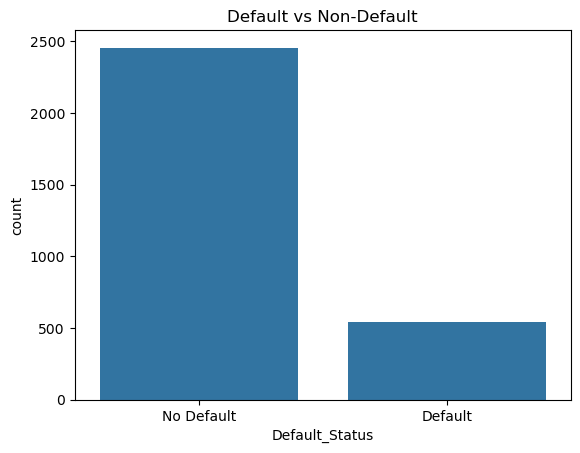

Default_Status
No Default    0.818667
Default       0.181333
Name: proportion, dtype: float64


In [35]:
sns.countplot(x='Default_Status', data=df)
plt.title("Default vs Non-Default")
plt.show()

print(df['Default_Status'].value_counts(normalize=True))

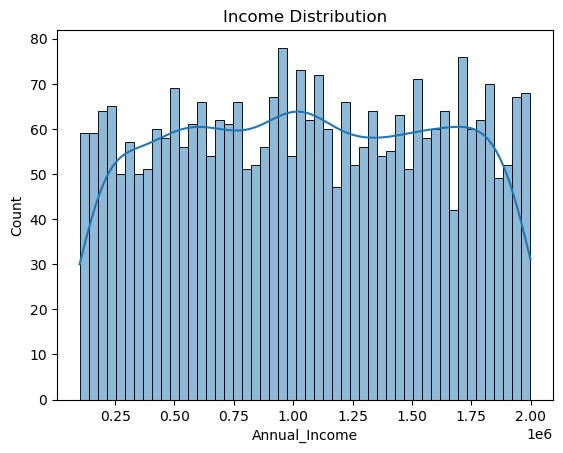

In [36]:
sns.histplot(df['Annual_Income'], bins=50, kde=True)
plt.title("Income Distribution")
plt.show()

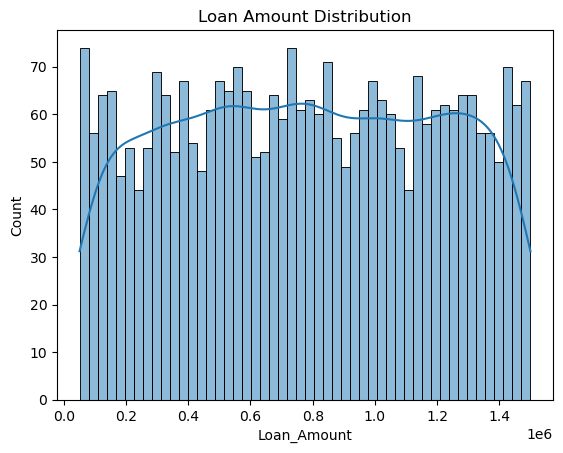

In [37]:
sns.histplot(df['Loan_Amount'], bins=50, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

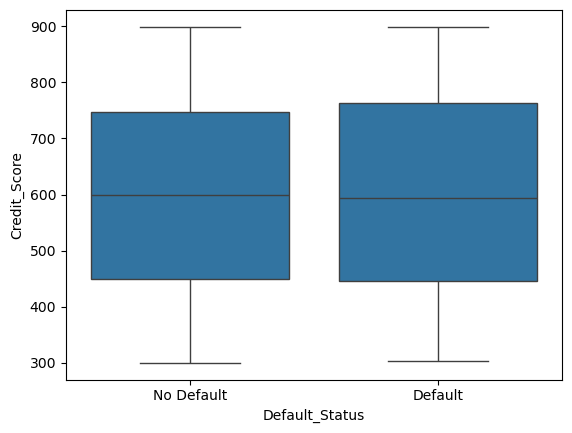

In [38]:
sns.boxplot(x='Default_Status', y='Credit_Score', data=df)
plt.show()

In [39]:
df.fillna(df.median(numeric_only=True),inplace=True)

df = pd.get_duummies(df, drop_first=True)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['Annual_Income', 'Loan_Amount', 'Credit_Score']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [41]:
from sklearn.model_selection import train_test_split

X = df.drop('Default_Status', axis=1)
y = df['Default_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
df['EMI_Income_Ratio'] = df['Loan_Amount'] / df['Annual_Income']

In [43]:
df['Credit_Band'] = pd.cut(df['Credit_Score'],
                          bins=[-3,-1,0,1,3],
                          labels=['Poor','Average','Good','Excellent'])

df = pd.get_dummies(df, columns=['Credit_Band'], drop_first=True)

In [44]:
df.drop(['Loan_Approved'], axis=1, inplace=True, errors='ignore')

In [45]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [46]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

C:\Users\Ruchi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5)

In [48]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [50,100],
          'max_depth': [3,5,7]}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [49]:
y_pred = best_model.predict(X_test)

In [50]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

     Default       0.00      0.00      0.00       109
  No Default       0.82      1.00      0.90       491

    accuracy                           0.82       600
   macro avg       0.41      0.50      0.45       600
weighted avg       0.67      0.82      0.74       600

ROC-AUC: 0.5204133111605224


C:\Users\Ruchi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ruchi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ruchi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')
print(scores.mean())

0.5022813020970431


In [52]:
import pickle

with open("loan_default_model.pkl", "wb") as f:
    pickle.dump(lr, f)

In [53]:
import pickle

with open("loan_default_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/Ruchi/Downloads/Loan_Default_Unclean_Dataset.csv")
df.head()

df.info()
df.describe()
df.isnull().sum()

sns.countplot(x='Default_Status', data=df)
plt.title("Default vs Non-Default")
plt.show()

print(df['Default_Status'].value_counts(normalize=True))

sns.histplot(df['Annual_Income'], bins=50, kde=True)
plt.title("Income Distribution")
plt.show()

sns.histplot(df['Loan_Amount'], bins=50, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

sns.boxplot(x='Default_Status', y='Credit_Score', data=df)
plt.show()

df.fillna(df.median(numeric_only=True),inplace=True)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['Annual_Income', 'Loan_Amount', 'Credit_Score']

df[num_cols] = scaler.fit_transform(df[num_cols])

from sklearn.model_selection import train_test_split

X = df.drop('Default_Status', axis=1)
y = df['Default_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

df['EMI_Income_Ratio'] = df['Loan_Amount'] / df['Annual_Income']

df['Credit_Band'] = pd.cut(df['Credit_Score'],
                          bins=[-3,-1,0,1,3],
                          labels=['Poor','Average','Good','Excellent'])

df = pd.get_dummies(df, columns=['Credit_Band'], drop_first=True)

df.drop(['Loan_Approved'], axis=1, inplace=True, errors='ignore')

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5)
rf.fit(X_train, y_train)

from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [50,100],
          'max_depth': [3,5,7]}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))

from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')
print(scores.mean())

